In [11]:
import pandas as pd 

In [12]:
df=pd.read_csv("./diabetes.csv")

In [13]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [15]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
age_category=[]
for i in df.Age:
    if i<30:
        age_category.append("young")
    elif i>30 and i<60:
        age_category.append("normal")
    else:
        age_category.append("old")

In [22]:
df["age_category_col"]=age_category

In [23]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,age_category_col
0,6,148,72,35,0,33.6,0.627,50,1,normal
1,1,85,66,29,0,26.6,0.351,31,0,normal
2,8,183,64,0,0,23.3,0.672,32,1,normal
3,1,89,66,23,94,28.1,0.167,21,0,young
4,0,137,40,35,168,43.1,2.288,33,1,normal


In [25]:
age_cat_data=df.age_category_col.value_counts()

In [32]:
age_cat_data

age_category_col
young     396
normal    319
old        53
Name: count, dtype: int64

In [28]:
import matplotlib.pyplot as plt

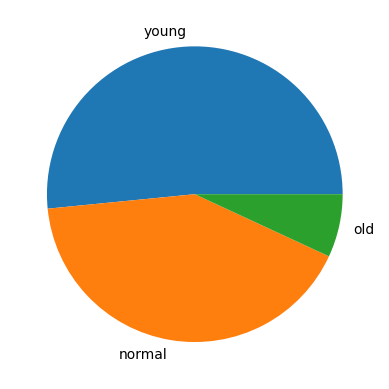

In [33]:
plt.pie(age_cat_data,labels=["young","normal","old"])
plt.show()

Inline transformation

In [36]:
df["agecat2"] = ["Young" if age < 40 else "Old" for age in df.Age]

In [37]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,age_category_col,agecat2
0,6,148,72,35,0,33.6,0.627,50,1,normal,Old
1,1,85,66,29,0,26.6,0.351,31,0,normal,Young
2,8,183,64,0,0,23.3,0.672,32,1,normal,Young
3,1,89,66,23,94,28.1,0.167,21,0,young,Young
4,0,137,40,35,168,43.1,2.288,33,1,normal,Young


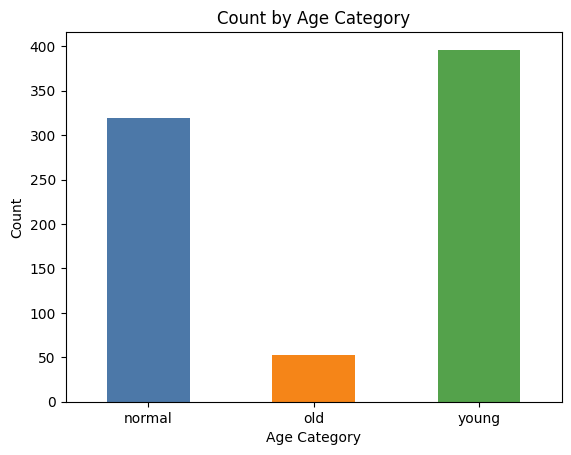

In [42]:
group_counts = df2.size().sort_index()

group_counts.plot(kind="bar", color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Count by Age Category")
plt.xlabel("Age Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [45]:
df2 = df.groupby("age_category_col")
# Display the size of each group
print(df2.size())

age_category_col
normal    319
old        53
young     396
dtype: int64


In [44]:
for name, group in df2:
    print(f"Group: {name}")
    print(group)
    print()

Group: normal
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
4              0      137             40             35      168  43.1   
8              2      197             70             45      543  30.5   
..           ...      ...            ...            ...      ...   ...   
756            7      137             90             41        0  32.0   
757            0      123             72              0        0  36.3   
761            9      170             74             31        0  44.0   
762            9       89             62              0        0  22.5   
766            1      126             60              0        0  30.1   

     DiabetesPedigreeFunction  Age  Outcome age_category_col agecat2  
0                       0.